В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [2]:
!pip install opendatasets --upgrade --quiet
import opendatasets as od
import os

In [3]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-5/data$0'

In [4]:
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: varvarakopyl
Your Kaggle Key: ··········


100%|██████████| 637k/637k [00:00<00:00, 38.7MB/s]


Extracting archive ./bank-customer-churn-prediction-dlu-course-c-5/bank-customer-churn-prediction-dlu-course-c-5.zip to ./bank-customer-churn-prediction-dlu-course-c-5


In [5]:
data_dir = './bank-customer-churn-prediction-dlu-course-c-5'

In [6]:
os.listdir(data_dir) # дивимось файли в директорії

['test.csv', 'sample_submission.csv', 'train.csv']

In [7]:
test_csv = data_dir + '/test.csv'
train_csv = data_dir + '/train.csv'
sample_submission_csv = data_dir + '/sample_submission.csv'

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv(train_csv)

In [10]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Exited"]) # розділяємо тренувальний набір, stratify зберігає розподіл класів 0 та 1 однаковий в обох наборах, аби уникнути перекосу

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [14]:
input_cols = list(train_df.columns)[1:-1] # x - колонки до достанньої НЕвключно
target_col = 'Exited' # y - остання колонка - цільова

In [15]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [16]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist() # np.number - узагальнений тип для числових даних
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [17]:
numeric_cols, categorical_cols

(['CustomerId',
  'CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 ['Surname', 'Geography', 'Gender'])

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

***Загальна статистика числових даних***

*Для перевірки адекватності*

In [18]:
train_inputs[numeric_cols].describe().round(2)

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,15690923.99,658.84,37.69,5.03,43008.17,1.59,0.79,0.49,117992.40
std,146930.97,72.33,8.14,2.78,59906.63,0.53,0.41,0.50,45589.48
min,1581102.00,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,15635116.00,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83343.73
50%,15689953.00,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123613.91
75%,15756921.50,708.00,42.00,7.00,109949.05,2.00,1.00,1.00,156912.81
max,15815690.00,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48


In [19]:
train_inputs[categorical_cols].nunique()

,0
Surname,732
Geography,3
Gender,2


***Кодування категоріальних колонок***

*Бінарні*

In [20]:
df.Gender.value_counts()

,count
Gender,
Male,8529
Female,6471


In [21]:
gender_codes = {'Male': 1, 'Female': 0}

In [22]:
train_df['Gender_code'] = train_df.Gender.map(gender_codes)
val_df['Gender_code'] = val_df.Gender.map(gender_codes)

*Номінальні*

*`Surname`*

In [23]:
from sklearn.preprocessing import OneHotEncoder

surname_enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
surname_enc.fit(train_inputs[['Surname']])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [24]:
surname_encoded_cols = list(surname_enc.get_feature_names_out(['Surname'])) # get_feature_names_out дозволяє згенерувати назви закодованих стовбців з використ. назви оригінального
print(surname_encoded_cols)

['Surname_Achebe', 'Surname_Ahern', 'Surname_Aikenhead', 'Surname_Aitken', 'Surname_Akabueze', 'Surname_Akhtar', 'Surname_Akobundu', 'Surname_Aksakova', 'Surname_Aksenov', 'Surname_Aksenova', 'Surname_Aksyonov', 'Surname_Aksyonova', 'Surname_Atherton', 'Surname_Avent', 'Surname_Azikiwe', 'Surname_Azubuike', 'Surname_Babbage', 'Surname_Baddeley', 'Surname_Bage', 'Surname_Bair', 'Surname_Bales', 'Surname_Balsillie', 'Surname_Bancks', 'Surname_Bancroft', 'Surname_Baresi', 'Surname_Baryshnikov', 'Surname_Bazarova', 'Surname_Bell', 'Surname_Bellucci', 'Surname_Bergamaschi', 'Surname_Bess', 'Surname_Bevan', 'Surname_Bibi', 'Surname_Binder', 'Surname_Biryukov', 'Surname_Biryukova', 'Surname_Bischof', 'Surname_Bitter', 'Surname_Black', 'Surname_Blesing', 'Surname_Bock', 'Surname_Bogle', 'Surname_Boulger', 'Surname_Bovee', 'Surname_Brazenor', 'Surname_Brient', 'Surname_Brierly', 'Surname_Brown', 'Surname_Brownless', 'Surname_Buchi', 'Surname_Bufkin', 'Surname_Burdekin', 'Surname_Burns', 'Surnam

In [25]:
train_inputs[surname_encoded_cols] = surname_enc.transform(train_inputs[['Surname']])
val_inputs[surname_encoded_cols] = surname_enc.transform(val_inputs[['Surname']])

/tmp/ipykernel_2844/4283224020.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[surname_encoded_cols] = surname_enc.transform(train_inputs[['Surname']])
/tmp/ipykernel_2844/4283224020.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[surname_encoded_cols] = surname_enc.transform(train_inputs[['Surname']])
/tmp/ipykernel_2844/4283224020.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joi

*`Geography`*

In [26]:
geo_enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
geo_enc.fit(train_inputs[['Geography']])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [27]:
geo_encoded_cols = list(geo_enc.get_feature_names_out(['Geography']))
print(geo_encoded_cols)

['Geography_France', 'Geography_Germany', 'Geography_Spain']


In [28]:
train_inputs[geo_encoded_cols] = geo_enc.transform(train_inputs[['Geography']])
val_inputs[geo_encoded_cols] = geo_enc.transform(val_inputs[['Geography']])

/tmp/ipykernel_2844/3014362671.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[geo_encoded_cols] = geo_enc.transform(train_inputs[['Geography']])
/tmp/ipykernel_2844/3014362671.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[geo_encoded_cols] = geo_enc.transform(train_inputs[['Geography']])
/tmp/ipykernel_2844/3014362671.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all col

In [29]:
try:
  train_inputs = train_inputs.drop(columns=categorical_cols)
except: KeyError

try:
  val_inputs = val_inputs.drop(columns=categorical_cols)
except: KeyError

***Масштабування***

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler().set_output(transform='pandas') # через set_output стандартизовані дані одразу повертаються в pandas, а не ndarray
scaler.fit(train_inputs)

StandardScaler()

In [32]:
train_inputs = scaler.transform(train_inputs)
val_inputs = scaler.transform(val_inputs)

In [33]:
train_inputs.head()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Surname_Achebe,...,Surname_Zhirov,Surname_Zikoranachidimma,Surname_Zito,Surname_Zox,Surname_Zuev,Surname_Zuyev,Surname_Zuyeva,Geography_France,Geography_Germany,Geography_Spain
7180,-0.263441,0.320187,-0.944682,-1.447264,1.475464,-1.108193,0.515062,1.016977,0.569450,-0.009129,...,-0.022366,-0.043822,-0.039823,-0.009129,-0.009129,-0.020417,-0.01826,0.814938,-0.467331,-0.530827
10393,-0.666919,0.347838,0.161227,-1.087792,2.254434,-1.108193,0.515062,-0.983306,0.603803,-0.009129,...,-0.022366,-0.043822,-0.039823,-0.009129,-0.009129,-0.020417,-0.01826,0.814938,-0.467331,-0.530827
80,0.569420,0.638166,-0.330288,0.350096,1.223831,0.769304,0.515062,-0.983306,1.238026,-0.009129,...,-0.022366,-0.043822,-0.039823,-0.009129,-0.009129,-0.020417,-0.01826,-1.227087,2.139813,-0.530827
3365,0.610162,0.140460,2.495924,-1.806736,-0.717950,0.769304,-1.941514,1.016977,-1.457116,-0.009129,...,-0.022366,-0.043822,-0.039823,-0.009129,-0.009129,-0.020417,-0.01826,-1.227087,-0.467331,1.883853
12236,-0.332313,0.665816,-2.050591,-0.728320,-0.717950,0.769304,0.515062,1.016977,0.670629,-0.009129,...,-0.022366,-0.043822,-0.039823,-0.009129,-0.009129,-0.020417,-0.01826,0.814938,-0.467331,-0.530827


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [34]:
!pip install pyarrow --quiet

In [35]:
# Папка з початковими файлами Kaggle
data_dir = "./bank-customer-churn-prediction-dlu-course-c-5"

# Створення всередині неї окрему папку для оброблених даних
processed_dir = os.path.join(data_dir, "processed_data")

os.makedirs(processed_dir, exist_ok=True) # makedirs створює папку processed_dir, якщо її ще немає (exist_ok - щоб не було помилки при повторному запуску комірки)

In [36]:
train_inputs.to_parquet(os.path.join(processed_dir, "train_inputs.parquet"))
val_inputs.to_parquet(os.path.join(processed_dir, "val_inputs.parquet"))

train_targets.to_frame().to_parquet(os.path.join(processed_dir, "train_targets.parquet"))
val_targets.to_frame().to_parquet(os.path.join(processed_dir, "val_targets.parquet"))

In [37]:
os.listdir(processed_dir)

['train_inputs.parquet',
 'train_targets.parquet',
 'val_targets.parquet',
 'val_inputs.parquet']

6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [38]:
X_train = train_inputs.copy()
X_val = val_inputs.copy()

In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear').fit(X_train, train_targets)

In [40]:
train_pred = model.predict(X_train) # розрахунок прогнозів класів 0 та 1 - повертає клас (0/1), який імовірніший для спостереження
val_pred = model.predict(X_val)

train_probs = model.predict_proba(X_train) # розрахунок прогнозних імовірностей - повертає дві імовірності (для кожного класу)
val_probs = model.predict_proba(X_val)

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

**Confusion matrix**

Cпосіб розбити об'єкти на чотири категорії (TN, FN, FP, TP) залежно від комбінації справжньої відповіді та відповіді алгоритму (моделі).

In [41]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [42]:
confusion_matrix(train_targets, train_pred)

array([[9171,  387],
       [ 959, 1483]])

Тренувальньна модель:

* TN - 9171
* FN - 959
* FP - 387
* TP - 1483




In [43]:
confusion_matrix(val_targets, val_pred)

array([[2240,  150],
       [ 276,  334]])

Валідаційна модель:

* TN - 2240
* FN - 276
* FP - 150
* TP - 334

In [44]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true') #normalize - дані нормалізовані, тобто частки вірно/хибно прогнозованих від усіх реальних позитивних/негативних
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 88.78%


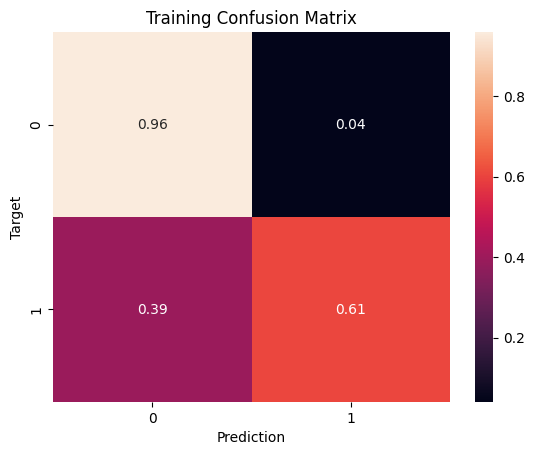

In [45]:
train_preds = predict_and_plot(X_train, train_targets, 'Training')

Accuracy: 85.80%


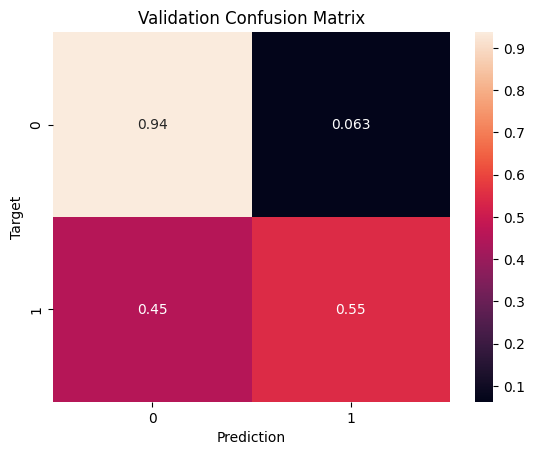

In [46]:
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

**F1-score** - гармонійне середнє точності та повноти
- гармонійне середнє, бо тяжіє до меншого значення (тому компенсації великим значенням меншого, як при сер. арифм. не буде)
- **високий F1 буде тільки при високих як recall, так і precision**

Необхідні поняття для розуміння: *Precision* та *Recall*

* Клас 1 - клієнт пішов
* Клас 0 - клієнт лишився (не пішов)

---

`PRECISION` (точність)

*Серед усіх клієнтів, яким **модель присвоїла клас 1**, скільки прогнозів відповідає реальності*

*Необхіність зʼясувати, чи багато "зайвих" прогнозів робить модель АБО наскільки `точні` наші прогнози*

TP / (TP + FP)

* TP - вірний прогноз класу 1
* (TP + FP) - усі прогнози класу 1 (ТР - вірні, FP - хибні)

334 / 484 = 0.69 - з усіх прогнозів класу 1 69% прогнозів виявились правильними

---

`RECALL` (повнота) = `TPR` (True Positive Rate)

*Cеред усіх клієнтів, які **реально пішли**, яку частину модель змогла виявити*

*Необхіність зʼясувати, чи багато "пропускає" модель АБО наскільки `повною мірою` модель може знайти клас 1*

TP / (TP + FN)

* TP - вірний прогноз класу 1
* (TP + FN) - усі реальні клієнти класу 1 (ТР - реально і прогнозовано клас 1, FN - реально клас 1, але прогнозовані як клас 0)

334 / 610 = 0.54 - з усіх реальних клієнтів класу 1 54% модель спрогнозувала вірно

`SPECIFICITY` = Recall для класу 0

---
`FPR` (False Posotive Rate)

*Частка реальних об’єктів класу 0, яких помилково назвали класом 1*

FP / (FP + TN)

* FP - реальний клас 0, але прогнозований як клас 1
* (FP + TN) - усі реальні клієнти класу 0 (FР - реальні клас 0, але прогнозовані як клас 1, TN - реально і прогнозовано клас 0)


In [47]:
from sklearn.metrics import f1_score

In [48]:
def get_f1_score(inputs, targets, name=''):
  preds = model.predict(inputs)

  f1_score_ = f1_score(targets, preds, pos_label=1)
  print(f"F1 score {name}: {f1_score_:.2f}%")

get_f1_score(X_train, train_targets, 'Training')
get_f1_score(X_val, val_targets, 'Validation')

F1 score Training: 0.69%
F1 score Validation: 0.61%


**AUROC & ROC-curve**

`ROC-крива` показує, як модель працює при всіх можливих порогах, а не лише при 0.5

* відображає відношення TPR до FPR за різних порогів класифікації
* вісь Х - FPR, вісь Y - TPR
* кожна точка кривої відповідає окремому порогу

---
1. Початкова точка при порогу 1 (0;0), так як клас 1 не визначається реально при такому високому порогу і FP, TP = 0. Отже, TPR, FPR = 0

*при доброму ранжуванні відбувається наступне*

2. Знижуємо поріг -> більше прогнозів потрапляє до класу 1 -> до певного моменту зростає к-сть TP, бо немає реальних класів 0, аби визначити як FP -> TPR зростає, FPR = 0 -> крива йде вгору по осі OY - "ідеальна ROC-крива"

3. При подальшому зниженні порога зʼявляється більше фактичних класів 0, але при цьому вони починають класифікуватися, як клас 1 -> зростає FPR -> напрям кривої зміщується вправо

4. Ще більше зниження порогу -> ще більше реального класу 0, класифікованих як клас 1 -> TPR сповільнюється, бо не зʼявляється нових TP, а FPR продовжує зростати -> крива повільніше рухається вгору, ніж вправо

3. Опустивши поріг до 0, майже всі спостереження класифікуються як клас 1 -> FN давно немає, тому TPR лишається 1 -> TN уже немає, тому FPR також дійшов до 1 -> кінцева точка (1;1)

`AUC ROC` (Area Under the ROC Curve) - площа під ROC-кривою

AUC вимірює всю двовимірну область під всією ривою ROC (як в інтегральному численні) від (0,0) до (1,1)

*Це ймовірність того, що випадково обраний об’єкт класу 1 отримає від моделі вищу оцінку ризику (ймовірність класу 1), ніж випадково обраний об’єкт класу 0. Тобто що в кожній парі обʼєкт з класу 1 матиме вищу ймовірність.*

* 1.0 — ідеальне ранжування (УСІ обʼєкти класу 1 з вищою ймовір.)
* 0.5 — випадкове ранжування - крива йде по діагоналі-бісектрисі, де класифікатор діє випадковим чином - вгадуванням класу (випадково присвоюється ймовірність в кожній парі)
* менше 0.5 — ранжування гірше випадкового (класи 1 з низькою ймовірністю, а класи 0 - з високою)

In [49]:
from sklearn.metrics import roc_curve, auc

def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.91


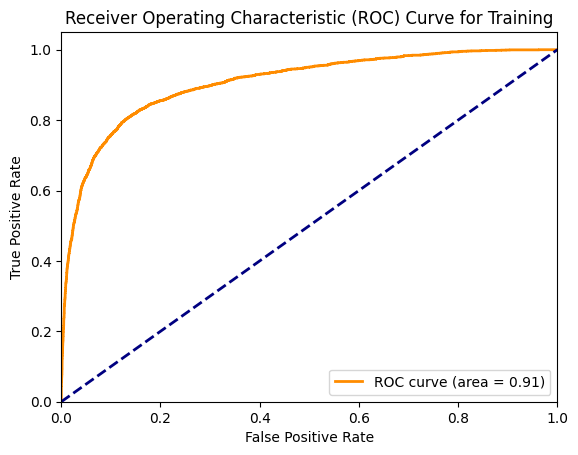

AUROC for Validation: 0.85


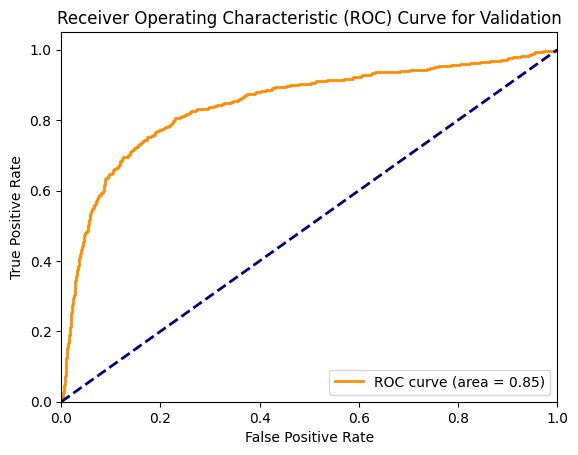

In [50]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

**ВИСНОВОК**

Модель має хорошу здатність ранжувати клієнтів за ризиком відтоку (клас 1 - не залишаться).

**`AUROC`** на тренувальній вибірці становить 0.91, що є дуже хорошим показником. При цьому на валідаційній вибірці становить 0.85, що несуттєво менше, до того ж враховуючи, що це валідаційні дані. Отже, AUC свідчить про близькість до ідеального ранжування моделлю ризиків при будь-якому порозі.

**`Confusion matrix`** свідчить, що модель на обох вибірках - тренувальній та валідаційній - добре класифікує дані, однак значно краще працює з даними класу 0, так як відсоток їх визначення є в межах 90%, у той час, як для класу 1 - 55%.

Водночас при порозі 0.5 модель на валідаційних даних знаходить лише близько 54.8% клієнтів (**`Recall`**) з усіх, які реально підуть. Хоча приблизно 69% її позитивних прогнозів є правильними (**`Precision`**). Сумнівний показник, так як модель "пропускає" близько 50% значень.

**`F1-score`** 0.61 для валідаційної вибірки (0.69 - тренувальна) підтверджує середні значення `Recall` та `Precision` і свідчить про посередній або задовільний баланс між ними.

Отже, модель є непоганою базовою моделлю. Загальне ранжування є дуже добрим, але все ще наявні неточності у виявлені класу 1. Для задачі активного виявлення відтоку потребує покращення або підбору іншого порога.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [51]:
train_targets.value_counts()

,count
Exited,
0.0,9558
1.0,2442


In [52]:
majority_class = 0

majority_train_pred = np.full(shape=len(train_targets), fill_value=majority_class) # створюємо масив такої самої довжини, як train_targets/val_targets, і заповнюємо його мажоритарним класом.

majority_val_pred = np.full(shape=len(val_targets),fill_value=majority_class)

In [53]:
# Accuracy обчислює частку об’єктів, для яких прогнозований клас збігається з реальним

majority_train_accuracy = accuracy_score(train_targets, majority_train_pred)
majority_val_accuracy = accuracy_score(val_targets, majority_val_pred)

print(f"Majority model - Train Accuracy: {majority_train_accuracy:.2%}")
print(f"Majority model - Validation Accuracy: {majority_val_accuracy:.2%}")

Majority model - Train Accuracy: 79.65%
Majority model - Validation Accuracy: 79.67%


In [54]:
model_train_accuracy = accuracy_score(train_targets, train_pred)

model_val_accuracy = accuracy_score(val_targets, val_pred)

print(f"Logistic Regression - Train Accuracy: {model_train_accuracy:.2%}")
print(f"Logistic Regression - Validation Accuracy: {model_val_accuracy:.2%}")

Logistic Regression - Train Accuracy: 88.78%
Logistic Regression - Validation Accuracy: 85.80%


**ВИСНОВОК**

Мажоритарним класом у тренувальній вибірці є клас 0, тому базова модель усім клієнтам прогнозує, що вони залишились в банку.

Незважаючи на відсутність навчання та повне ігнорування ознак, така модель має Accuracy близько 79.7% як на тренувальній, так і на валідаційній вибірці. Високе значення пояснюється дисбалансом класів: приблизно 80% клієнтів належать до класу 0, тому частка класу 0 буде висока (через те, що дуже багато реальних клієнтів класу 0). Проблема в тому, що **ця модель не знайшла ЖОДНОГО втікача, її високий accuracy штучний, так як зумовлений дисбалансом класів. Модель не приносить корисних інсайтів.**

Логістична регресія має Accuracy 88.8% на тренувальних і 85.8% на валідаційних даних. Отже, логістична регресія справді виявила корисні закономірності в даних і працює краще за базове прогнозування мажоритарного класу.

Водночас оцінювати модель лише за Accuracy некоректно. Базова модель із Accuracy майже 80% не знаходить жодного клієнта класу 1, а її Recall та F1 для цього класу дорівнюють нулю. Логістична регресія знаходить близько 54.8% реального відтоку та має F1 близько 0.61. Тому її можна вважати задовільною базовою моделлю, але не достатньо сильною для задачі, де важливо виявляти більшість клієнтів, які не залишаться в банку.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [55]:
import joblib

In [56]:
bank_churn = {
    'model': model,
    'scaler': scaler,
    'gender_codes': gender_codes,
    'surname_encoder': surname_enc,
    'geo_encoder': geo_enc,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'surname_encoded_cols': surname_encoded_cols,
    'geo_encoded_cols': geo_encoded_cols,
    'model_cols': X_train.columns.tolist()
}

In [57]:
joblib.dump(bank_churn, 'log_reg.joblib')

['log_reg.joblib']

In [58]:
model_2 = joblib.load('log_reg.joblib')

In [59]:
# Перевірка на валідаційному наборі
val_preds2 = model_2['model'].predict(X_val)
accuracy_score(val_targets, val_preds2)

0.858

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [60]:
# import warnings
# warnings.filterwarnings("ignore")

# def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
#     input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
#     input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
#     X_input = input_df[numeric_cols + encoded_cols]
#     prob = model.predict_proba(X_input)[:,1]
#     return prob

In [61]:
# predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, raw_df[:5])

In [70]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(saved_objects, input_df: pd.DataFrame):
    input_df = input_df.copy()

    # 1. Кодуємо Gender
    input_df["Gender_code"] = input_df["Gender"].map(saved_objects["gender_codes"])

    # 2. Кодуємо Surname
    input_df[saved_objects["surname_encoded_cols"]] = saved_objects["surname_encoder"].transform(input_df[["Surname"]])

    # 3. Кодуємо Geography
    input_df[saved_objects["geo_encoded_cols"]] = saved_objects["geo_encoder"].transform(input_df[["Geography"]])

    # 4. Беремо ті самі колонки й у тому самому порядку, на яких навчався scaler через feature_names_in_
    model_cols = saved_objects["scaler"].feature_names_in_
    X_input = input_df[model_cols] # бере з input_df лише ті колонки, назви яких містяться у model_cols, і записує отриману таблицю у X_input

    # 5. Масштабуємо
    X_input = saved_objects["scaler"].transform(X_input)

    # 6. Повертаємо ймовірність класу 1: клієнт не залишиться в банку
    prob = saved_objects["model"].predict_proba(X_input)[:, 1] # [:, 1] - всі рядки і другу колонку (де ймовірності класу 1, а в першій - класу 0)

    return prob

In [63]:
# Виклик
# predict_raw_df(model_2, raw_df)

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [71]:
test_raw_df = pd.read_csv(test_csv)

In [72]:
test_raw_df["Exited"] = predict_raw_df(model_2, test_raw_df)

test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.018115
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.070492
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.067390
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.430724
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.000213


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [73]:
sample_submission = pd.read_csv(sample_submission_csv)

In [74]:
sample_submission["Exited"] = sample_submission["id"].map(test_raw_df.set_index("id")["Exited"])

In [75]:
sample_submission.head()

,id,Exited
0,15000,0.018115
1,15001,0.070492
2,15002,0.067390
3,15003,0.430724
4,15004,0.000213


In [76]:
sample_submission.to_csv("submission_log_reg.csv", index=False)